<a href="https://colab.research.google.com/github/tianlangxingaerfa/Python/blob/main/ASTRON16_LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASTRON 16 Lab 1 - Measuring the Astronomical Unit

## Using the Doppler effect to measure $v_\mathrm{rot}$ of the Sun!

### Please enter your name in this cell. (press 'esc m' to make a markdown cell or 'run')
Wolf Hu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units
from astropy import constants

# Part 1: Doppler Shift

You will need to download the fits images (files with the extension .FIT) that we took in lab from the Canvas site. Make sure to download the images from your lab section! Enter the path to the directory (folder where you saved the images) that contains your fits files and the filenames of your fits files. I recommend saving your images in the same directory as your notebook.

If using Google colab, run the following cell and upload the fits files.

In [ ]:
# Type the path to your directory in quotes, ending in /, to signal it is a directory.
# If you uploaded your files to Google Colab using the above cell, you shouldn't need to
# change this.
path = './' # you can keep this if your FITS files are in the same directory as this notebook.

# Enter the names of all 8 fits files, individually in quotations, then separated by a comma
# into the list called filenames.
filenames=['2026-02-24-T1.FIT', '2026-02-24-TR1.FIT', '2026-02-24-R1.FIT', '2026-02-24-BR1.FIT',
           '2026-02-24-B1.FIT', '2026-02-24-BL1.FIT', '2026-02-24-L1.FIT', '2026-02-24-TL1.FIT']

### Let's look at all our fits images.

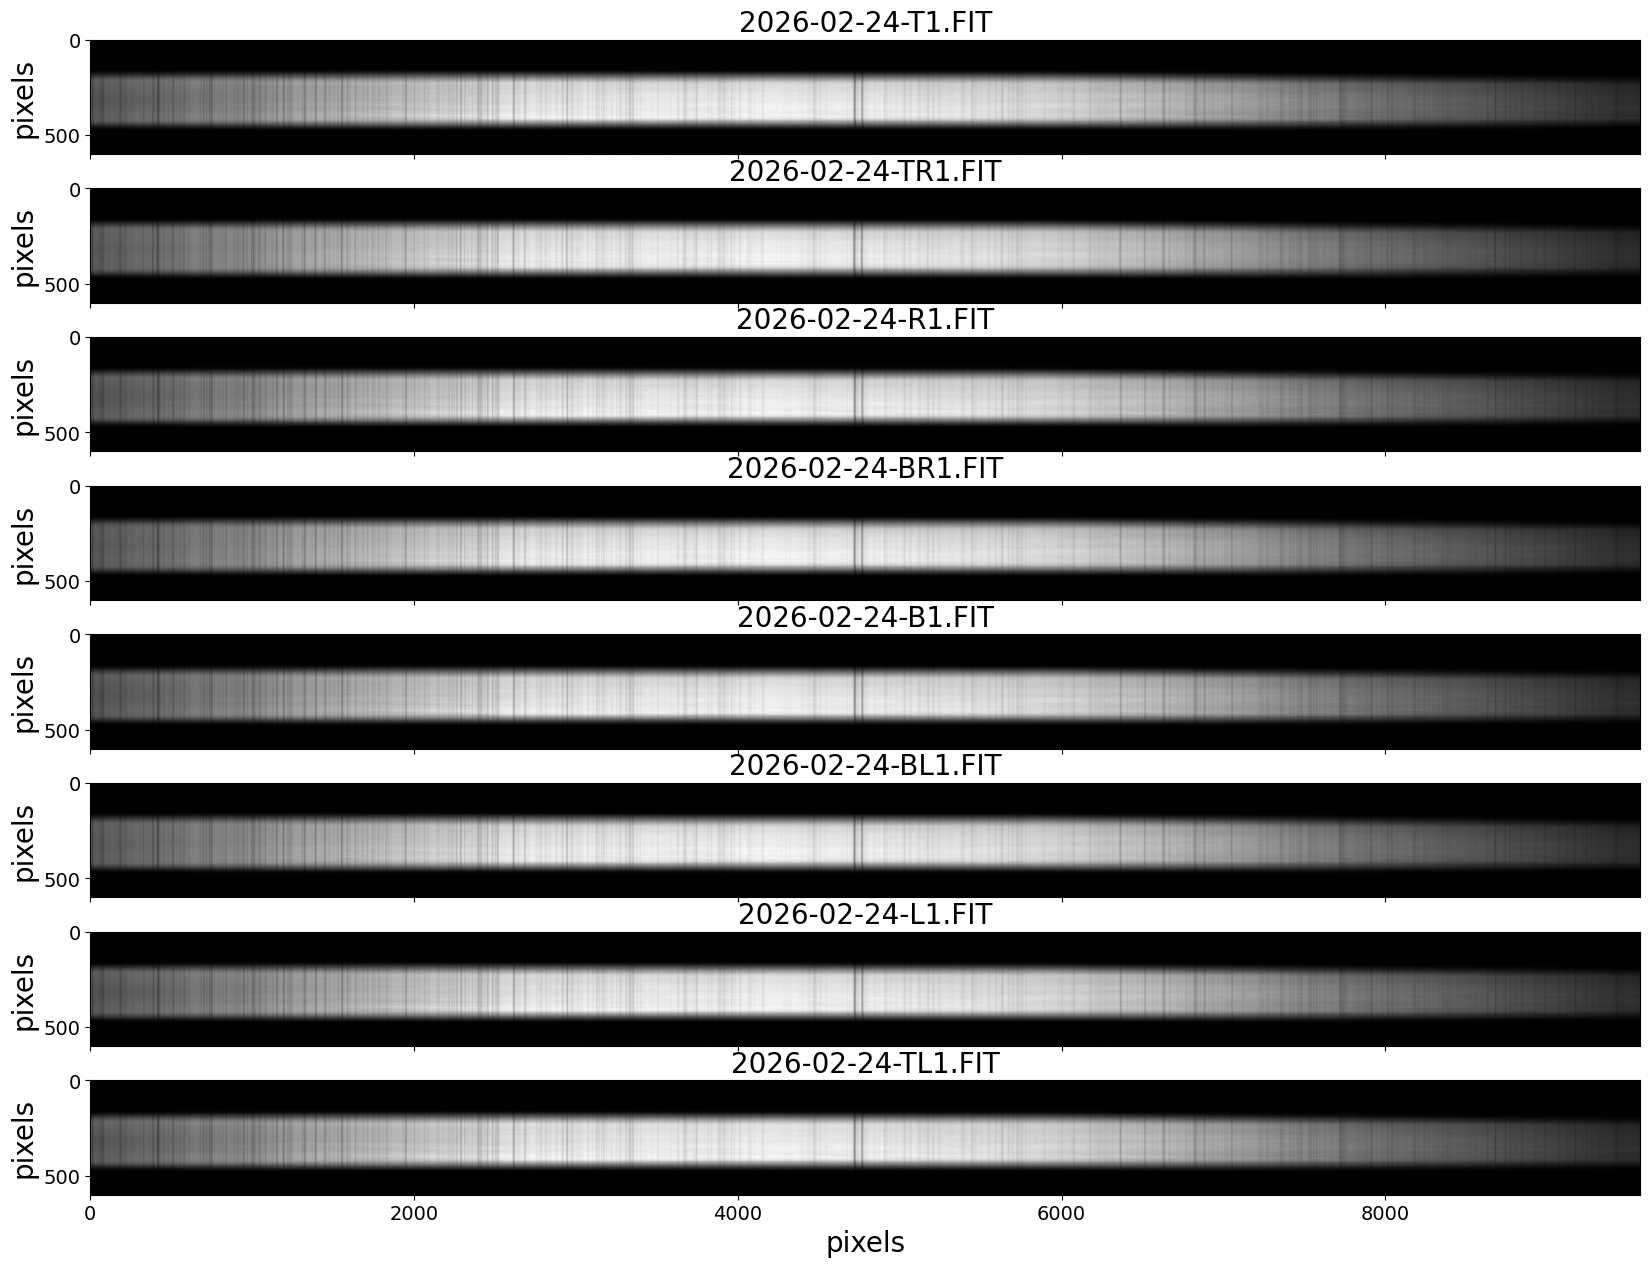

In [ ]:
# This cell plots all of your fits images in a grid.
# The name of each file will be printed on top of each image

fs = 20 # fontsize of your titles and labels

# plt.subplots creates a grid of plots, so you can plot multiple images in 1 figure
# the arguments are (# of rows, # of columns, size of figure, whether to share x and y axes)
fig, ax = plt.subplots(len(filenames), 1, figsize=(20,15), sharex=True)

for i,file in enumerate(filenames): # loop through each file that you listed above
    image = fits.getdata(path+file, ext=0)
    # the lines below plot the image on the ith ax object, which corresponds to the ith subplot
    ax[i].imshow(image, cmap='gray', aspect='auto')
    ax[i].set_title(file, fontsize=fs)
    ax[i].tick_params(labelsize=14)
    ax[i].set_ylabel('pixels', fontsize=fs)

ax[-1].set_xlabel('pixels', fontsize=fs) # set pixel label on the bottom plot
plt.subplots_adjust(wspace=0.1, hspace=0.3) # adjust the spacing between subplots

### Now lets select one file to look at in closer detail.
### We will then select a "slice" of the image in order to plot our spectra.

In [ ]:
# Enter the name of the file you wish to look at more closely
selected_file = '2026-02-24-TR1.FIT'

# Now let's make an object we can plot
selected_image = fits.getdata(path+selected_file, ext=0)

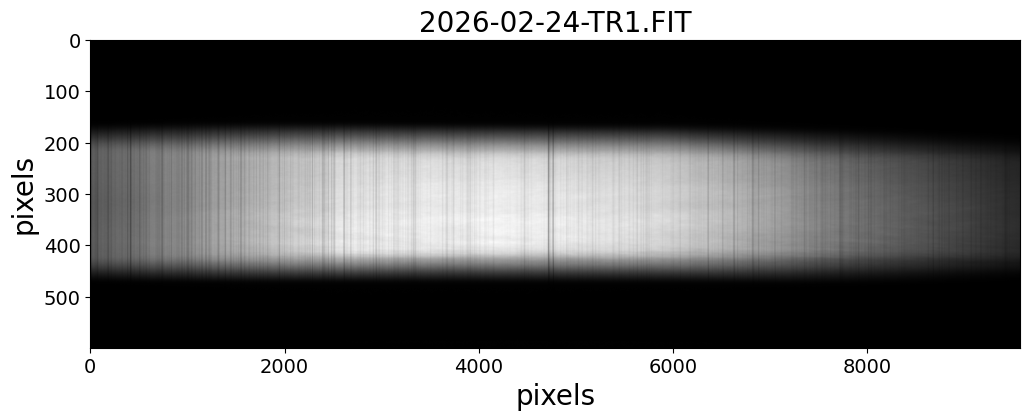

In [ ]:
plt.figure(figsize=(12,4)) # for just one plot, you don't need to use plt.subplots
plt.imshow(selected_image, cmap='gray', aspect='auto')
plt.title(selected_file, fontsize=fs)
plt.tick_params(labelsize=14)
plt.xlabel('pixels', fontsize=fs)
plt.ylabel('pixels', fontsize=fs)
plt.show()

In [ ]:
# This is to check that your image has the right dimensions - it should be (600, 9576)
print('The dimensions of the image are', selected_image.shape)

The dimensions of the image are (600, 9576)


In [ ]:
#This function normalizes the data to get the data on the same scale.
def norm(data, low=None, high=None):
    '''
    This function normalizes the selected data for plotting the spectra.

    parameters
    ---------
    data: nd-array, slice of fits file
    low: lower pixel limit
    high: upper pixel limit

    returns:
    -------
    1d-array, normed intensity of spectra
    '''
    if low == None or high == None: # if low or high is not specified, use all data
        low = 0
        high = data.shape[1]

    data_cut = data[:, low:high]
    I_mean = np.mean(data_cut, axis=0) # calculates the mean across all rows for each column (mean along vertical slices)
    I_median = np.median(I_mean) # takes median of the mean values across all columns to get a single value for the whole spectrum
    data_norm = I_mean/I_median

    return data_norm


### Let's select the "slice"

We now want to select a region of the image that cuts a small (~30-100 vertical pixel by the full horizontal pixel) region of the image. Your TF will help guide you through this if you have questions.

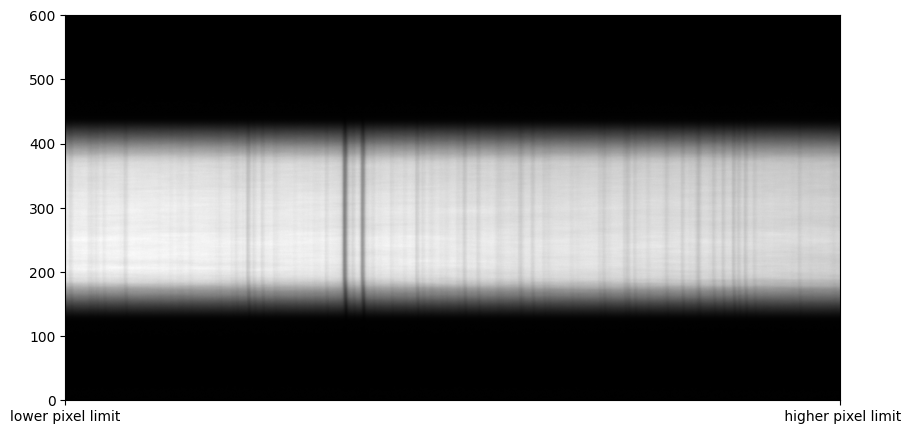

In [ ]:
# Type the boundaries of the "slice".
# You can keep adjusting the bounds until you get a slice you want to use.
# Remember: we want both Na D lines and the Telluric line!
#     Reference the online Solar spectrum (http://bass2000.obspm.fr/solar_spect.php) and compare
#     with the solar atlas (http://astrosurf.com/spectrohelio/atlas-en.php) to ensure that you include
#     a water line in your images

#boundaries in terms of pixel number (reference plot above)
low = 'lower pixel limit'
high = ' higher pixel limit'

# keep the same pixel positions for the x-axis when you zoom
pixels = np.arange(4000, 6000)

#make the slice
image_slice = selected_image[: , 4000:6000]

#plot
plt.figure(figsize=(10,5))
plt.imshow(image_slice,
           cmap='gray',
           aspect='auto',
           extent=[low, high, 0, image_slice.shape[0]] # the extent allows us to keep the same pixel positions for the x-axis
           )
plt.show()

### If your lab took more than 2 spectra, run the code below. If not, you can skip to the next block starting at selecting the two spectra.

Let's plot the spectra of all 8 images using the extracted slices.

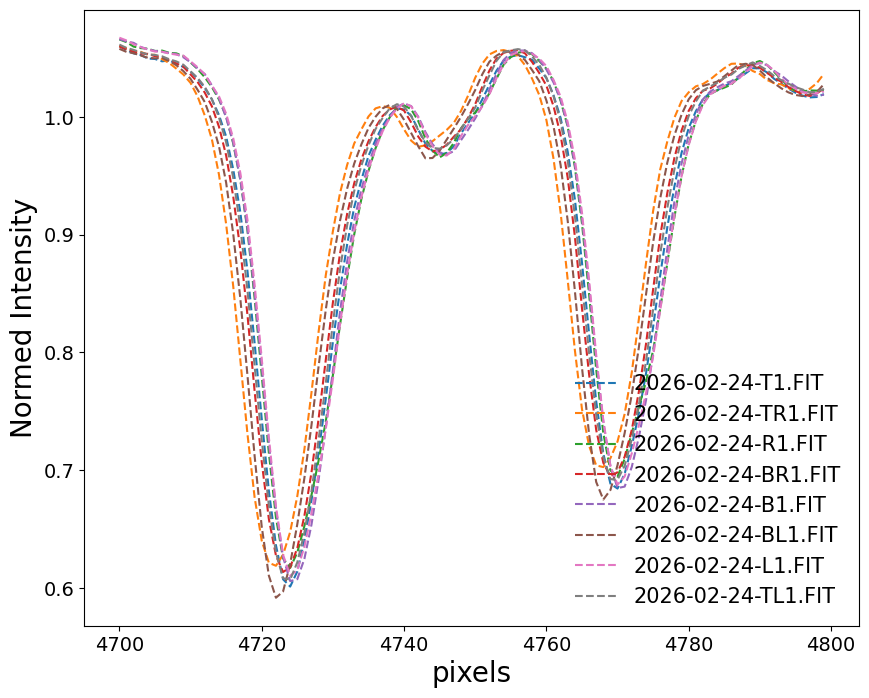

In [ ]:
#This cell plots all 8 normed spectra
fig = plt.figure(figsize = (10,8))
pixels = np.arange(4700, 4800)
for i,file in enumerate(filenames):
    image      = fits.getdata(path+file, ext=0)
    norm_slice = norm(image, 4700, 4800)
    plt.plot(pixels, norm_slice, linestyle='dashed', label=file)
plt.tick_params(labelsize=14)
plt.xlabel('pixels', fontsize=fs)
# plt.xlim(4700, 4800) # adjust xlimits to zoom in
plt.ylabel('Normed Intensity', fontsize=fs)
plt.legend(loc="lower right", fontsize=15, frameon=False)
plt.show()

### Select the two spectra for which you notice the greatest shift.

In [ ]:
spectra_1 = '2026-02-24-TR1.FIT'
spectra_2 = '2026-02-24-BL1.FIT'
spectrum_1 = norm(fits.getdata(path+spectra_1, ext=0))
spectrum_2 = norm(fits.getdata(path+spectra_2, ext=0))

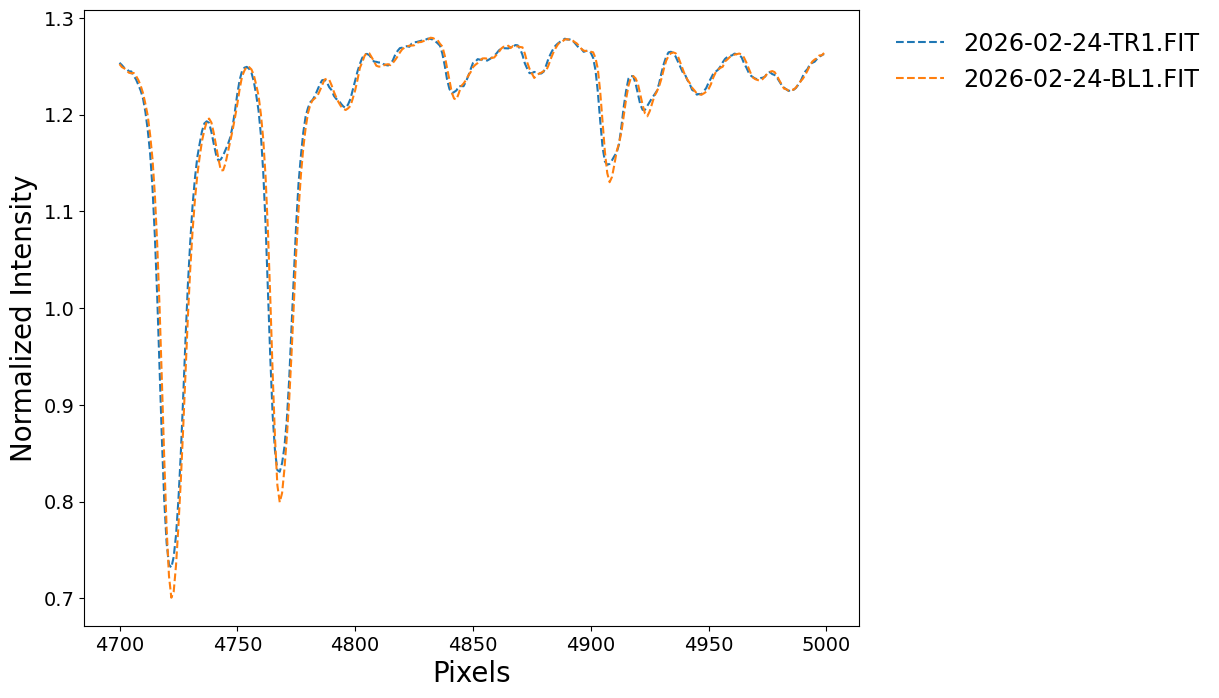

In [33]:
#This cell plots the 2 normalized spectra chosen above
fig = plt.figure(figsize = (10,8))

pixels = np.arange(4700, 5000)
plt.plot(pixels, spectrum_1[4700:5000], linestyle='dashed', label=spectra_1)
plt.plot(pixels, spectrum_2[4700:5000]
         , linestyle='dashed', label=spectra_2)
plt.tick_params(labelsize=14)
plt.xlabel('Pixels', fontsize=fs)
plt.ylabel('Normalized Intensity', fontsize=fs)
plt.legend(bbox_to_anchor=(1.02, 1), fontsize='xx-large', frameon=False)
plt.show()

How does it look? Can you see a clear Doppler effect? If not, you can use the next section to looked at the zoomed plots.

# Part 2: Determining $v_\mathrm{rot}$

### First we need to fit the curves of the absorption lines
We do this by selecting a range in pixels that "zooms in" to where our absorption lines are at the minimum. This will help us select a narrow range of the spectra to fit later on.

In [ ]:
def zoom_in(data, lowpix, highpix):
    '''
    This function makes a cut, "zoom-in", to the absorption line minimums.

    parameters
    ----------
    data: 1d-array, normed spectrum
    lowpix: int, lower pixel boundary
    highpix: int, upper pixel boundary

    returns
    ----------
    1d-array, pixels between where minimums lie
    1d-array, region of spectra where minimums lie
    '''
    pixels = np.arange(0, data.shape[0])

    # this function returns two outputs, so we can unpack them into two variables
    return pixels[lowpix:highpix],data[lowpix:highpix]

In [ ]:
### Define your zoomed-in ranges for the left line
lowpix_left = 4715
highpix_left = 4730
NaD_1_b1 = zoom_in(spectrum_1, lowpix_left, highpix_left)
NaD_1_r1 = zoom_in(spectrum_2, lowpix_left, highpix_left)

In [ ]:
### Define your zoomed-in ranges for the right line
lowpix_right = 4760
highpix_right = 4775
NaD_2_b1 = zoom_in(spectrum_1, lowpix_right, highpix_right)
NaD_2_r1 = zoom_in(spectrum_2, lowpix_right, highpix_right)

In [34]:
### Define your zoomed-in ranges for the Telluric
lowpix_telluric = 4790
highpix_telluric = 4805
H2O_b1 = zoom_in(spectrum_1, lowpix_telluric, highpix_telluric)
H2O_r1 = zoom_in(spectrum_2, lowpix_telluric, highpix_telluric)

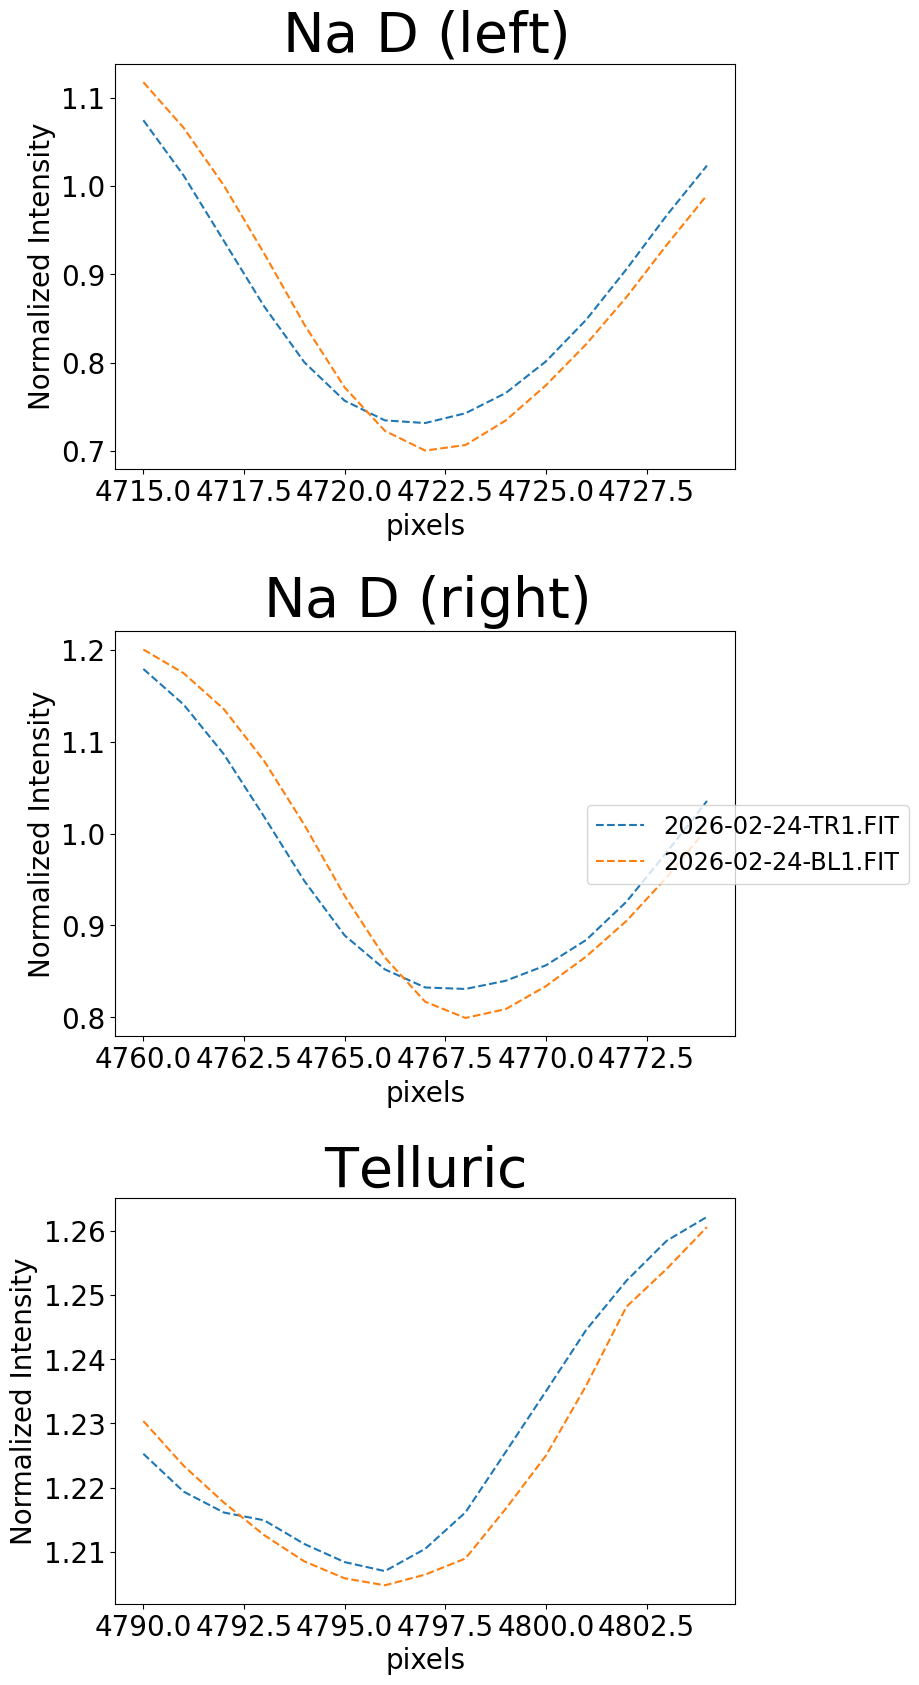

In [35]:
# if you want to check out ways to customize your plots, check out the Matplotlib documentation!
fig, ax = plt.subplots(3,1,figsize = (8,20))
ax[0].plot(NaD_1_b1[0],NaD_1_b1[1], label = spectra_1, linestyle='dashed')
ax[0].plot(NaD_1_r1[0], NaD_1_r1[1], label = spectra_2, linestyle='dashed')
ax[0].set_title(r'$\mathrm{Na\ D\ (left)}$',fontsize=40)

ax[1].plot(NaD_2_b1[0],NaD_2_b1[1], label = spectra_1, linestyle='dashed')
ax[1].plot(NaD_2_r1[0], NaD_2_r1[1], label = spectra_2, linestyle='dashed')
ax[1].set_title(r'$\mathrm{Na\ D\ (right)}$',fontsize=40)

ax[2].plot(H2O_b1[0], H2O_b1[1], label = spectra_1, linestyle='dashed')
ax[2].plot(H2O_r1[0], H2O_r1[1], label = spectra_2, linestyle='dashed')
ax[2].set_title(r'$\mathrm{Telluric}$',fontsize=40)
for i in range(3):
    ax[i].tick_params(labelsize=20)
    ax[i].set_xlabel('pixels', fontsize=fs)
    ax[i].set_ylabel('Normalized Intensity', fontsize=fs);
plt.legend(bbox_to_anchor=(1.3, 2), fontsize='xx-large');
plt.subplots_adjust(hspace=0.4)

### These resemble polynomial functions. We now fit these curves in order to obtain the pixel value where the true minimum occurs.

In [36]:
# This the polynomial we will use to fit our data
def poly(x,a,b,c):
    '''
    This function reurns a parabola with given input.

    parameters
    ----------
    x: 1D-array, the independent variable, in our case, pixel values
    a,b,c : floats, the coefficients of our parabolic function

    returns
    ---------
    1D-array, the fitted normed intensity as a function of pixel values'''

    y = a*x**2 + b*x +c
    return y

#### Fit the curves

In [37]:
# curve_fit is a really powerful function that allows us to fit any function we want to our data!
from scipy.optimize import curve_fit

In [38]:
#it's useful to begin with some guess to help the optimizer find the best fit parameters
# this should be a guess for a, b, and c
guess = [0.5, 1.0, 400]

In [39]:
# We only need the parameters, not the covariance, so we will take index[0] of curve_fit
NaD_1_b1_params = curve_fit(poly, NaD_1_b1[0], NaD_1_b1[1], p0=guess)[0]
NaD_1_r1_params = curve_fit(poly, NaD_1_r1[0], NaD_1_r1[1], p0=guess)[0]

In [40]:
NaD_2_b1_params = curve_fit(poly, NaD_2_b1[0], NaD_2_b1[1], p0=guess)[0]
NaD_2_r1_params = curve_fit(poly, NaD_2_r1[0], NaD_2_r1[1], p0=guess)[0]

In [41]:
H2O_b1_params = curve_fit(poly, H2O_b1[0], H2O_b1[1], p0=guess)[0]
H2O_r1_params = curve_fit(poly, H2O_r1[0], H2O_r1[1], p0=guess)[0]

#### We create a new set of values based on our fit parameters. Remember, you may need to make minor adjustments to improve the fit of your curves.

In [42]:
# here, we are calculating the fitted values for the line at the pixel values in the zoomed-in range (NaD_1_b1[0] and NaD_1_r1[0])
# the parameters come from our curve_fit results above
NaD_1_b1_fit = poly(NaD_1_b1[0],NaD_1_b1_params[0], NaD_1_b1_params[1],NaD_1_b1_params[2])
NaD_1_r1_fit = poly(NaD_1_r1[0],NaD_1_r1_params[0], NaD_1_r1_params[1],NaD_1_r1_params[2])

In [43]:
NaD_2_b1_fit = poly(NaD_2_b1[0],NaD_2_b1_params[0], NaD_2_b1_params[1],NaD_2_b1_params[2])
NaD_2_r1_fit = poly(NaD_2_r1[0],NaD_2_r1_params[0], NaD_2_r1_params[1],NaD_2_r1_params[2])

In [44]:
H2O_b1_fit = poly(H2O_b1[0],H2O_b1_params[0], H2O_b1_params[1],H2O_b1_params[2])
H2O_r1_fit = poly(H2O_r1[0],H2O_r1_params[0], H2O_r1_params[1],H2O_r1_params[2])

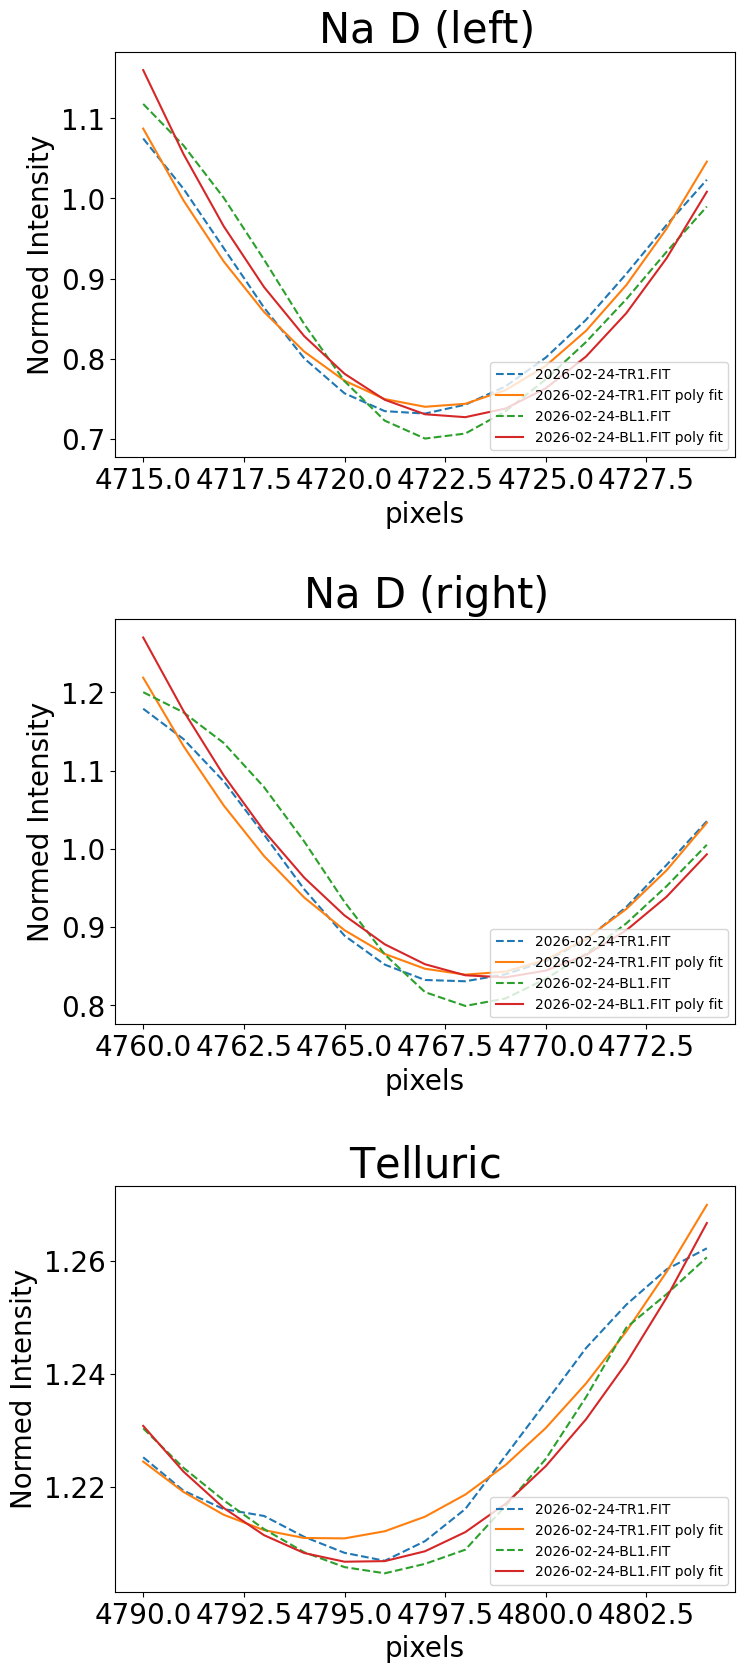

In [45]:
fig, ax = plt.subplots(3,1,figsize = (8,20))
ax[0].plot(NaD_1_b1[0],NaD_1_b1[1], label = spectra_1, linestyle='dashed')
ax[0].plot(NaD_1_b1[0],NaD_1_b1_fit, label = spectra_1+' poly fit')

ax[0].plot(NaD_1_r1[0], NaD_1_r1[1], label = spectra_2, linestyle='dashed')
ax[0].plot(NaD_1_r1[0],NaD_1_r1_fit, label = spectra_2+' poly fit')
ax[0].set_title(r'$\mathrm{Na\ D\ (left)}$',fontsize=30)

ax[1].plot(NaD_2_b1[0],NaD_2_b1[1], label = spectra_1, linestyle='dashed')
ax[1].plot(NaD_2_b1[0],NaD_2_b1_fit, label = spectra_1+' poly fit')
ax[1].plot(NaD_2_r1[0], NaD_2_r1[1], label = spectra_2, linestyle='dashed')
ax[1].plot(NaD_2_r1[0],NaD_2_r1_fit, label = spectra_2+' poly fit')
ax[1].set_title(r'$\mathrm{Na\ D\ (right)}$',fontsize=30)

ax[2].plot(H2O_b1[0],H2O_b1[1], label = spectra_1, linestyle='dashed')
ax[2].plot(H2O_b1[0],H2O_b1_fit, label = spectra_1+' poly fit')
ax[2].plot(H2O_r1[0], H2O_r1[1], label = spectra_2, linestyle='dashed')
ax[2].plot(H2O_r1[0],H2O_r1_fit, label = spectra_2+' poly fit')
ax[2].set_title(r'$\mathrm{Telluric}$',fontsize=30)
for i in range(3):
    ax[i].tick_params(labelsize=20)
    ax[i].set_xlabel('pixels', fontsize=fs)
    ax[i].set_ylabel('Normed Intensity', fontsize=fs)
    ax[i].legend(loc ='lower right')
plt.subplots_adjust(hspace=0.4)
plt.show()

## Now it's time to do our calculations

In [46]:
def poly_min(a,b):
    '''
    This function returns the minimum values from our polynomial fit parameters.

    parameters
    ----------
    a,b: float, the values of the coefficients of our polynomial

    returns
    ----------
    float: minimum value (recall that the minimum of a parabola ax^2 + bx + c is at x = -b/2a)
    '''
    return -b/(2*a)

In [47]:
### Get the minimum values
min_NaD_1_b1_fit = poly_min(NaD_1_b1_params[0],NaD_1_b1_params[1])
min_NaD_1_r1_fit = poly_min(NaD_1_r1_params[0],NaD_1_r1_params[1])
min_NaD_2_b1_fit = poly_min(NaD_2_b1_params[0],NaD_2_b1_params[1])
min_NaD_2_r1_fit = poly_min(NaD_2_r1_params[0],NaD_2_r1_params[1])

min_H2O_b1_fit = poly_min(H2O_b1_params[0],H2O_b1_params[1])
min_H2O_r1_fit = poly_min(H2O_r1_params[0],H2O_r1_params[1])

We will calculate our $v_\mathrm{rot}$ in the following manner:

$$\frac{\Delta \lambda}{\lambda}=\frac{v}{c}$$
$$v_\mathrm{rot}=\frac{c \Delta \lambda}{2 \lambda}$$

where $\Delta \lambda$ comes from our measuremnts and $\lambda = \lambda_\mathrm{emitted}$

In [48]:
#let's define some constants
c=constants.c.to('km/s') # speed of light in km/s
# these are the rest frame wavelengths of NaD
left_emitted = 5889.96 #emission of left NaD in Angstroms
right_emitted = 5895.94 #emission of right NaD in Angstroms

In [49]:
# This cell calculates the conversion factor of pixel to Angstrom
# conversion is 5.97/ the separation between the left and right lines
conversion = 5.97/(min_NaD_2_b1_fit-min_NaD_1_b1_fit)

In [50]:
def V_rot(min_1, min_2, lambda_emitted):
    '''
    This function calculates the rotational velocity given the Doppler shift of
    wavelengths at which the absorption lines are at minimum and the emitted absorption lines

    parameters
    ----------
    min_1, min2: float, the wavelengths of the doppler shifted absorption lines
    lambda_emitted: float, the emitted wavelength

    returns
    --------
    float: the rotational velocity
    '''

    pixel_separation = np.abs(min_2-min_1)
    Delta_lambda = pixel_separation*conversion
    v = Delta_lambda/lambda_emitted * c
    return (v/2).to('km/s')

### And finally we obtain:

#### The rotational velocity

In [51]:
Vrot_left = V_rot(min_NaD_1_b1_fit, min_NaD_1_r1_fit, left_emitted)
Vrot_left

<Quantity 1.75377224 km / s>

In [52]:
Vrot_right = V_rot(min_NaD_2_b1_fit, min_NaD_2_r1_fit, right_emitted)
Vrot_right

<Quantity 1.90494802 km / s>

In [53]:
np.mean([Vrot_left.value, Vrot_right.value])

np.float64(1.8293601264013832)

#### The offset of the Telluric line in pixels -- > this value should be close to zero

In [54]:
np.round(min_H2O_b1_fit-min_H2O_r1_fit, 6)

np.float64(-0.883905)